In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def cPower(soc, v_min, v_max, i_cc, i_cutoff, soc_trans, B):
    """CC-CV charging power function"""
    soc = np.atleast_1d(soc)
    cc = soc < soc_trans
    v = v_min + (v_max - v_min) * (soc / soc_trans)
    i = i_cutoff + (i_cc - i_cutoff) * np.exp(-B * (soc - soc_trans))
    return np.where(cc, i_cc * v, v_max * i)

In [5]:
def energy_cost(soc1, soc2, v_min, v_max, i_cc, i_cutoff, soc_trans, B, cap, price):
    """Calculate energy (kWh) and cost ($)"""
    soc = np.linspace(soc1, soc2, 1000)
    P = cPower(soc, v_min, v_max, i_cc, i_cutoff, soc_trans, B)
    i = np.where(soc < soc_trans, i_cc, i_cutoff + (i_cc - i_cutoff) * np.exp(-B * (soc - soc_trans)))
    dt = cap * (soc[1] - soc[0]) / i
    E_kwh = np.trapz(P, dt) / 1000
    return E_kwh * price, E_kwh

/tmp/ipykernel_3436688/3248583477.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_kwh = np.trapz(P, dt) / 1000


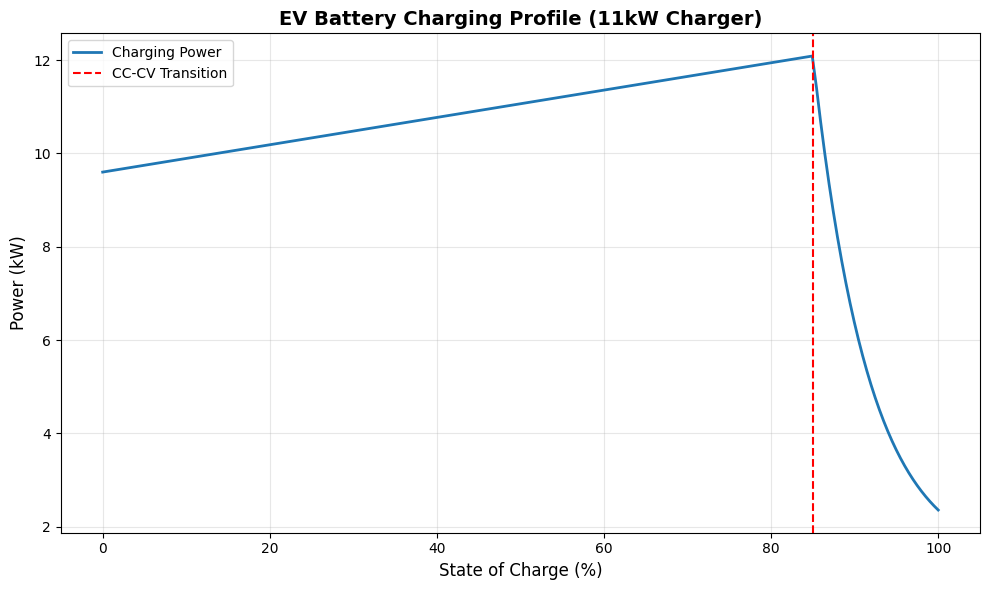


Charging from 20% to 80% SoC (recommended range)
Energy consumed: 0.00 kWh
Electricity cost: $0.00
Charging time: ~0.0 hours
Range added: ~0 km (@ 250 Wh/km)


In [7]:
# Example: Tesla Model 3 Standard Range equivalent
# 60kWh battery (approx 170Ah at 350V nominal), 11kW home charger
soc = np.linspace(0, 1, 200)
P = cPower(soc, 320, 403, 30, 3, 0.85, 15)
cost, energy = energy_cost(0.2, 0.8, 320, 403, 30, 3, 0.85, 15, 170, 0.15)

plt.figure(figsize=(10, 6))
plt.plot(soc*100, P/1000, linewidth=2, label='Charging Power')
plt.axvline(85, color='r', linestyle='--', label='CC-CV Transition')
plt.xlabel('State of Charge (%)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.title('EV Battery Charging Profile (11kW Charger)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

print(f"\n{'='*50}")
print(f"Charging from 20% to 80% SoC (recommended range)")
print(f"Energy consumed: {energy:.2f} kWh")
print(f"Electricity cost: ${cost:.2f}")
print(f"Charging time: ~{energy/10:.1f} hours")
print(f"Range added: ~{energy*4:.0f} km (@ 250 Wh/km)")
print(f"{'='*50}")